<a href="https://colab.research.google.com/github/gauravbhatia-bit/demand-forecasting-engine/blob/main/P1_Demand_Forecasting_Gaurav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Multi-SKU Demand Forecasting Engine
**Gaurav Bhatia** — MSc Data Science | GISMA University, Berlin  
**Models:** ARIMA · Prophet · XGBoost  
**Dataset:** Kaggle Store Item Demand Forecasting  

---
### How to use this notebook
1. Run cells **top to bottom** (Shift+Enter or Runtime → Run All)
2. Upload `train.csv` from Kaggle when prompted in **Step 1**
3. See interactive charts and model comparison at the end
4. Launch the Streamlit app in the last cell


## ⚙️ Step 0 — Install Libraries
Run this once. Takes about 2–3 minutes.

In [4]:
# Install all required libraries
# The ! means: run this as a terminal command inside Colab
!pip install -q pandas numpy scikit-learn statsmodels prophet xgboost optuna plotly joblib pyngrok streamlit

print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.7 MB/s eta 0:00:00
✅ All libraries installed successfully!


## 📥 Step 1 — Upload Dataset from Kaggle

**How to get the data (FREE):**
1. Go to: https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data
2. Sign in to Kaggle (free account)
3. Click **Download All** → extract the ZIP
4. You will find `train.csv` — upload it using the cell below


In [1]:
from google.colab import files
import os

print("📂 Please upload train.csv from Kaggle...")
print("If you already uploaded it, skip this cell.\n")

uploaded = files.upload()   # A file picker dialog will appear

# Check it was uploaded
if "train.csv" in uploaded:
    print(f"✅ train.csv uploaded successfully! Size: {len(uploaded['train.csv'])/1024:.1f} KB")
elif os.path.exists("train.csv"):
    print("✅ train.csv already exists in this session.")
else:
    print("⚠️ Upload did not complete. Please try again.")

📂 Please upload train.csv from Kaggle...
If you already uploaded it, skip this cell.



Saving train.csv to train (1).csv
✅ train.csv already exists in this session.


## 🔧 Step 2 — Prepare & Explore the Data

We convert daily sales → weekly per-SKU format.  
We pick the top 12 best-selling items as our 12 SKUs.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Load raw data ──────────────────────────────────────────────────────────────
print("Loading train.csv...")
df_raw = pd.read_csv("train.csv", parse_dates=["date"])
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print()
print("First 5 rows:")
df_raw.head()

Loading train.csv...
Raw data shape: (913000, 4)
Columns: ['date', 'store', 'item', 'sales']
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00

First 5 rows:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
# ── Convert daily → weekly, pick store 1, top 12 items ────────────────────────
df_raw["week_start"] = df_raw["date"].dt.to_period("W-MON").apply(lambda r: r.start_time)

weekly = (df_raw
          .groupby(["week_start", "store", "item"])["sales"]
          .sum()
          .reset_index()
          .rename(columns={"week_start": "date", "sales": "demand"}))

# Keep only Store 1 for simplicity
weekly = weekly[weekly["store"] == 1].copy()

# Top 12 items by total demand
top_items = (weekly.groupby("item")["demand"]
             .sum().nlargest(12).index.tolist())
weekly = weekly[weekly["item"].isin(top_items)].copy()

# Create readable SKU names
item_map = {item: f"SKU_{str(i+1).zfill(2)}_Item_{item}"
            for i, item in enumerate(sorted(top_items))}
weekly["sku"] = weekly["item"].map(item_map)
weekly = weekly[["date","sku","demand"]].sort_values(["sku","date"]).reset_index(drop=True)

# Save for later use
weekly.to_csv("weekly_sales.csv", index=False)

print(f"✅ Weekly data prepared!")
print(f"Shape: {weekly.shape}")
print(f"SKUs: {list(weekly['sku'].unique())}")
print(f"Date range: {weekly['date'].min().date()} to {weekly['date'].max().date()}")
print()
weekly.head(8)

✅ Weekly data prepared!
Shape: (3132, 3)
SKUs: ['SKU_01_Item_8', 'SKU_02_Item_10', 'SKU_03_Item_12', 'SKU_04_Item_13', 'SKU_05_Item_15', 'SKU_06_Item_18', 'SKU_07_Item_22', 'SKU_08_Item_25', 'SKU_09_Item_28', 'SKU_10_Item_36', 'SKU_11_Item_38', 'SKU_12_Item_45']
Date range: 2013-01-01 to 2017-12-26



,date,sku,demand
0,2013-01-01,SKU_01_Item_8,301
1,2013-01-08,SKU_01_Item_8,268
2,2013-01-15,SKU_01_Item_8,289
3,2013-01-22,SKU_01_Item_8,263
4,2013-01-29,SKU_01_Item_8,298
5,2013-02-05,SKU_01_Item_8,315
6,2013-02-12,SKU_01_Item_8,268
7,2013-02-19,SKU_01_Item_8,338


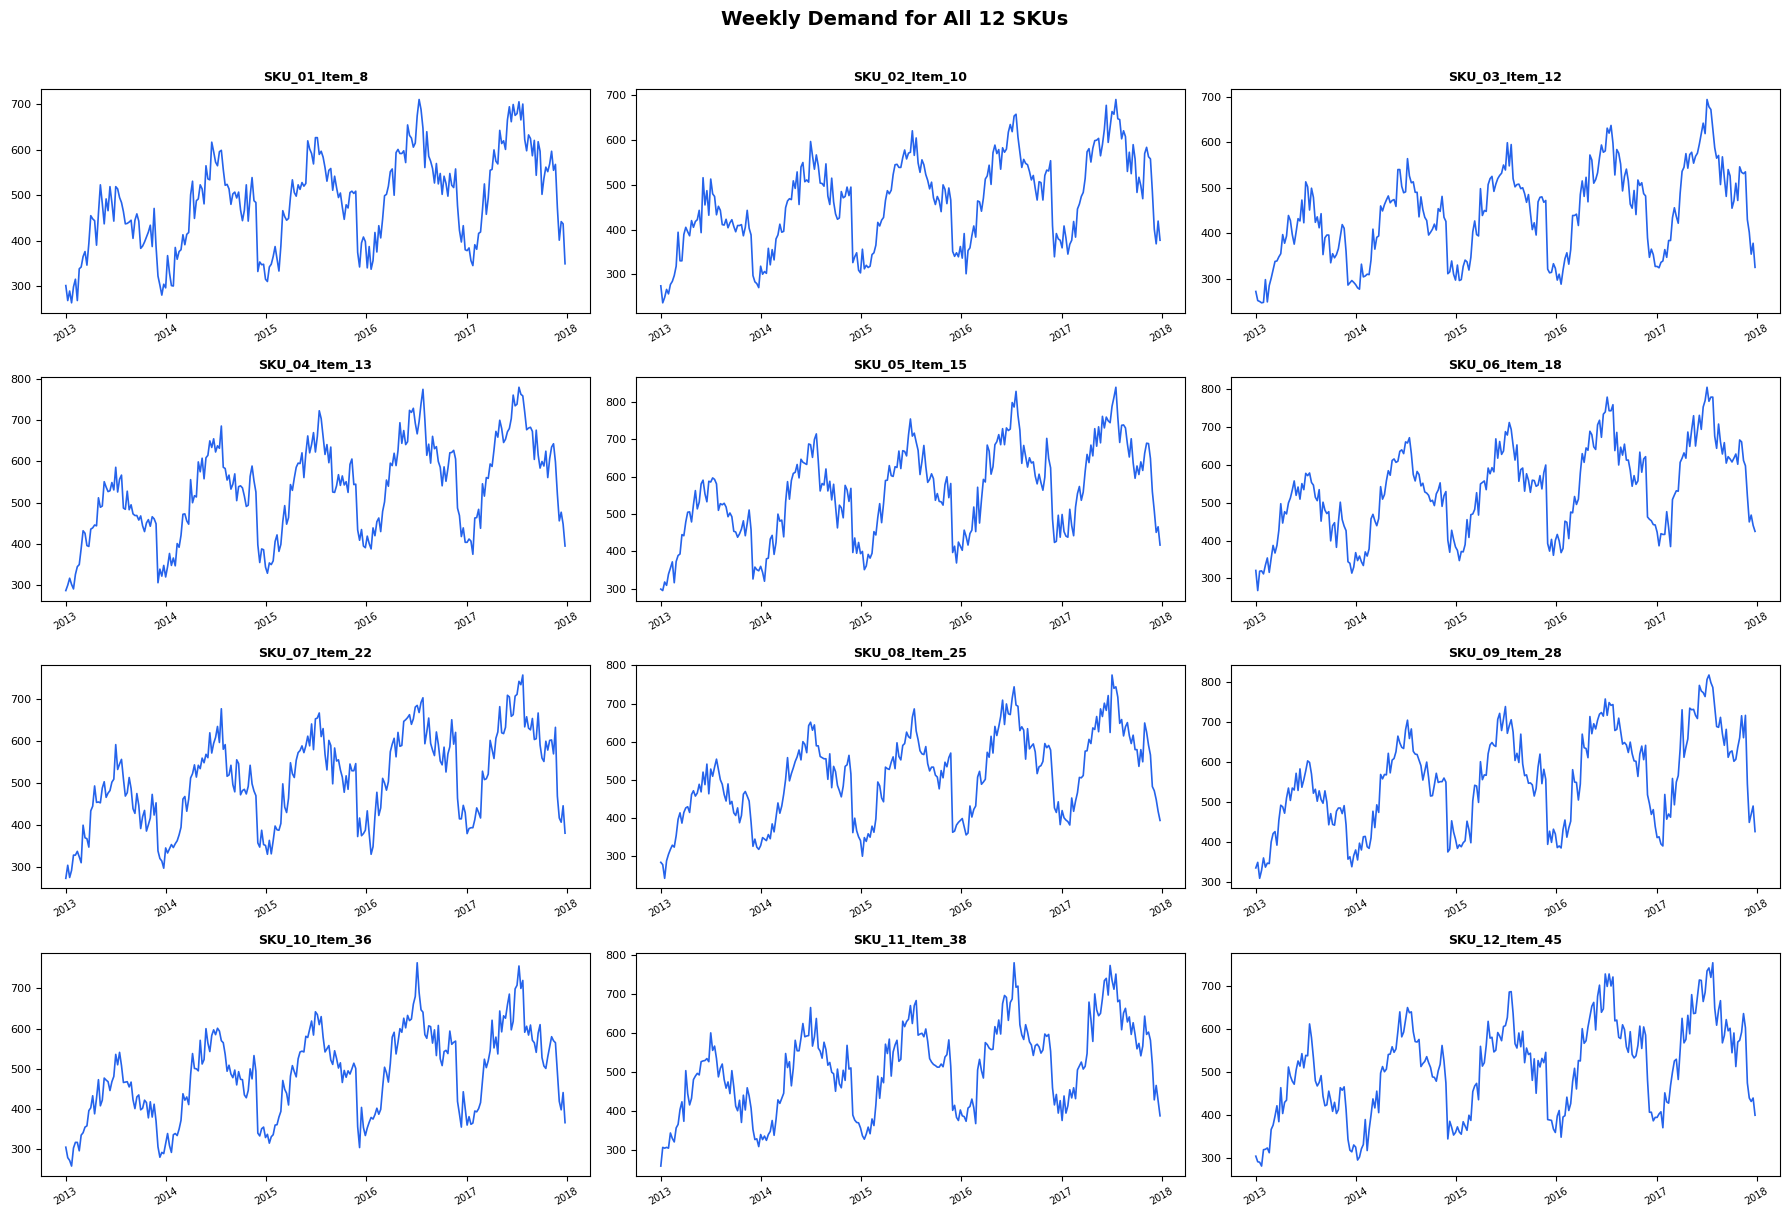

✅ Demand plots saved as sku_demand_overview.png


In [4]:
# ── Plot demand for all 12 SKUs ────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
skus = sorted(weekly["sku"].unique())

for i, sku in enumerate(skus):
    sku_data = weekly[weekly["sku"] == sku]
    axes[i].plot(sku_data["date"], sku_data["demand"], linewidth=1.2, color="#2563EB")
    axes[i].set_title(sku, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=7, rotation=30)
    axes[i].tick_params(axis="y", labelsize=8)

plt.suptitle("Weekly Demand for All 12 SKUs", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sku_demand_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Demand plots saved as sku_demand_overview.png")

## 🔨 Step 3 — Feature Engineering

We add extra columns that help ML models learn patterns:
- **Lag features**: demand from 1, 2, 4, 8, 13, 26, 52 weeks ago
- **Rolling statistics**: average and std deviation over past windows
- **Calendar features**: week number, month, quarter, year

> ⚠️ We always shift features BACKWARDS so the model never sees future data (no data leakage)


In [5]:
def engineer_features(df):
    """Add lag, rolling, and calendar features to weekly sales data."""
    df = df.copy().sort_values(["sku","date"]).reset_index(drop=True)

    # Calendar features — tells model about seasonal patterns
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["month"]        = df["date"].dt.month
    df["quarter"]      = df["date"].dt.quarter
    df["year"]         = df["date"].dt.year

    # Lag features — what was demand N weeks ago?
    for lag in [1, 2, 4, 8, 13, 26, 52]:
        df[f"lag_{lag}"] = df.groupby("sku")["demand"].shift(lag)

    # Rolling statistics — average and variability over past N weeks
    for w in [4, 8, 13, 26]:
        df[f"rolling_mean_{w}"] = (df.groupby("sku")["demand"]
                                   .transform(lambda x: x.shift(1).rolling(w).mean()))
        df[f"rolling_std_{w}"]  = (df.groupby("sku")["demand"]
                                   .transform(lambda x: x.shift(1).rolling(w).std()))

    df = df.dropna().reset_index(drop=True)
    return df

def get_feature_cols(df):
    return [c for c in df.columns if c not in ["date","sku","demand"]]

def split_sku(df, sku, test_weeks=12):
    s = df[df["sku"]==sku].copy().reset_index(drop=True)
    return s.iloc[:-test_weeks], s.iloc[-test_weeks:]

# Apply feature engineering
df_weekly = pd.read_csv("weekly_sales.csv", parse_dates=["date"])
df_feat   = engineer_features(df_weekly)

print(f"✅ Feature engineering done!")
print(f"Shape before: {df_weekly.shape}  →  After: {df_feat.shape}")
print(f"New features added: {get_feature_cols(df_feat)}")

✅ Feature engineering done!
Shape before: (3132, 3)  →  After: (2508, 22)
New features added: ['week_of_year', 'month', 'quarter', 'year', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_13', 'rolling_std_13', 'rolling_mean_26', 'rolling_std_26']


## 📈 Step 4a — ARIMA Forecasting

ARIMA is a classic statistical model for time series.  
We automatically find the best (p,d,q) parameters by minimising AIC score.


✅ ARIMA on SKU_01_Item_8
Best order: (1, 1, 2)
Metrics: {'MAE': np.float64(64.04), 'RMSE': np.float64(82.7), 'MAPE%': np.float64(14.79)}


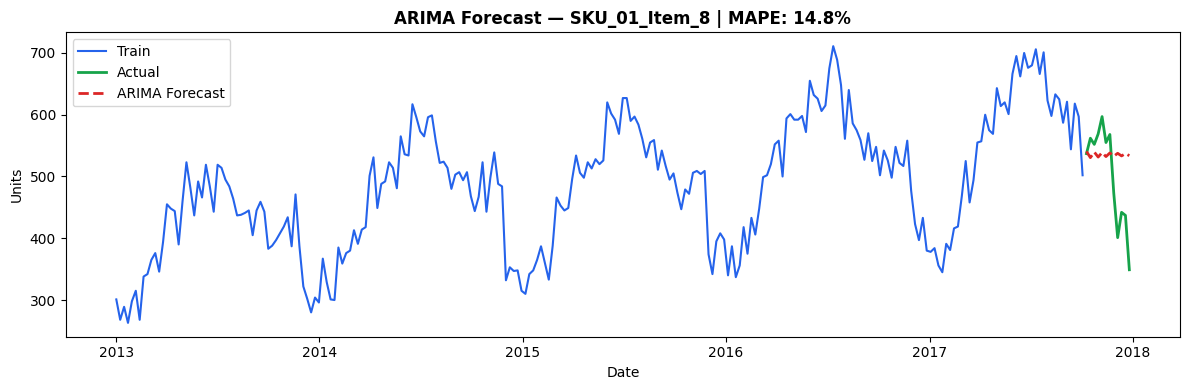

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

def find_best_arima(series):
    """Try all (p,d,q) combinations and return the one with lowest AIC."""
    best_aic, best_order = np.inf, (1,1,1)
    for p,d,q in product(range(0,3), range(0,2), range(0,3)):
        try:
            res = ARIMA(series, order=(p,d,q)).fit()
            if res.aic < best_aic:
                best_aic, best_order = res.aic, (p,d,q)
        except:
            continue
    return best_order

def run_arima(train_series, test_steps):
    order  = find_best_arima(train_series)
    model  = ARIMA(train_series, order=order).fit()
    preds  = np.maximum(0, model.forecast(steps=test_steps).values)
    return preds, order

def calc_metrics(actual, predicted):
    mae  = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    mape = np.mean(np.abs((actual - predicted) / np.maximum(actual, 1))) * 100
    return {"MAE": round(mae,2), "RMSE": round(rmse,2), "MAPE%": round(mape,2)}

# ── Test ARIMA on one SKU ──────────────────────────────────────────────────────
TEST_SKU    = skus[0]
TEST_WEEKS  = 12

raw_sku     = df_weekly[df_weekly["sku"]==TEST_SKU].sort_values("date")
arima_train = raw_sku["demand"].iloc[:-TEST_WEEKS]
arima_test  = raw_sku["demand"].iloc[-TEST_WEEKS:].values

preds_arima, best_order = run_arima(arima_train, TEST_WEEKS)
metrics_arima = calc_metrics(arima_test, preds_arima)

print(f"✅ ARIMA on {TEST_SKU}")
print(f"Best order: {best_order}")
print(f"Metrics: {metrics_arima}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw_sku["date"].iloc[:-TEST_WEEKS], arima_train.values, label="Train", color="#2563EB", linewidth=1.5)
ax.plot(raw_sku["date"].iloc[-TEST_WEEKS:], arima_test, label="Actual", color="#16A34A", linewidth=2)
ax.plot(raw_sku["date"].iloc[-TEST_WEEKS:], preds_arima, label="ARIMA Forecast", color="#DC2626", linewidth=2, linestyle="--")
ax.set_title(f"ARIMA Forecast — {TEST_SKU} | MAPE: {metrics_arima['MAPE%']:.1f}%", fontweight="bold")
ax.legend(); ax.set_xlabel("Date"); ax.set_ylabel("Units")
plt.tight_layout(); plt.savefig("arima_forecast.png", dpi=120, bbox_inches="tight"); plt.show()

## 📈 Step 4b — Facebook Prophet Forecasting

Prophet handles trends and seasonality automatically.  
It requires the data in a DataFrame with columns named `ds` (date) and `y` (value).


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


✅ Prophet on SKU_01_Item_8
Metrics: {'MAE': np.float64(26.15), 'RMSE': np.float64(38.06), 'MAPE%': np.float64(6.03)}


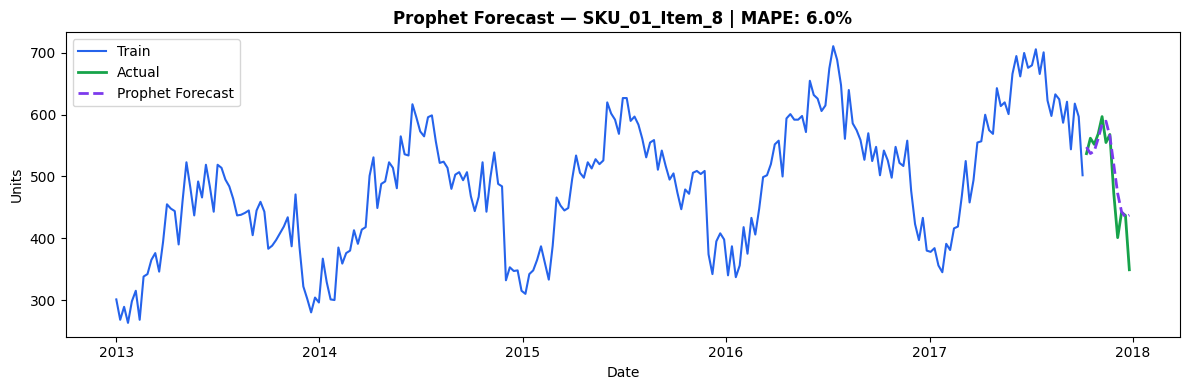

In [7]:
import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
from prophet import Prophet

def run_prophet(train_df, test_steps):
    prophet_df = train_df[["date","demand"]].rename(columns={"date":"ds","demand":"y"})
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    changepoint_prior_scale=0.05, interval_width=0.95)
    model.fit(prophet_df)
    future   = model.make_future_dataframe(periods=test_steps, freq="W")
    forecast = model.predict(future)
    preds    = np.maximum(0, forecast["yhat"].values[-test_steps:])
    return preds, forecast

# ── Test Prophet on same SKU ──────────────────────────────────────────────────
prophet_train = raw_sku.iloc[:-TEST_WEEKS]
prophet_test  = raw_sku["demand"].iloc[-TEST_WEEKS:].values

preds_prophet, forecast_df = run_prophet(prophet_train, TEST_WEEKS)
metrics_prophet = calc_metrics(prophet_test, preds_prophet)

print(f"✅ Prophet on {TEST_SKU}")
print(f"Metrics: {metrics_prophet}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw_sku["date"].iloc[:-TEST_WEEKS], prophet_train["demand"].values,
        label="Train", color="#2563EB", linewidth=1.5)
ax.plot(raw_sku["date"].iloc[-TEST_WEEKS:], prophet_test,
        label="Actual", color="#16A34A", linewidth=2)
ax.plot(raw_sku["date"].iloc[-TEST_WEEKS:], preds_prophet,
        label="Prophet Forecast", color="#7C3AED", linewidth=2, linestyle="--")
ax.set_title(f"Prophet Forecast — {TEST_SKU} | MAPE: {metrics_prophet['MAPE%']:.1f}%", fontweight="bold")
ax.legend(); ax.set_xlabel("Date"); ax.set_ylabel("Units")
plt.tight_layout(); plt.savefig("prophet_forecast.png", dpi=120, bbox_inches="tight"); plt.show()

## 📈 Step 4c — XGBoost Forecasting with Optuna Tuning

XGBoost uses all the engineered features (lags, rolling stats, calendar).  
Optuna automatically finds the best hyperparameters using TimeSeriesSplit cross-validation.

> ⏱️ **This cell takes 2–4 minutes** because Optuna tries 20 different settings.  
> Set `TUNE = False` for a fast run with default settings.


  Best params: {'n_estimators': 294, 'max_depth': 3, 'learning_rate': 0.09116208418406618, 'subsample': 0.8337227753600017, 'colsample_bytree': 0.6452430061054695, 'random_state': 42, 'verbosity': 0}

✅ XGBoost on SKU_01_Item_8
Metrics: {'MAE': np.float64(34.09), 'RMSE': np.float64(38.11), 'MAPE%': np.float64(7.11)}


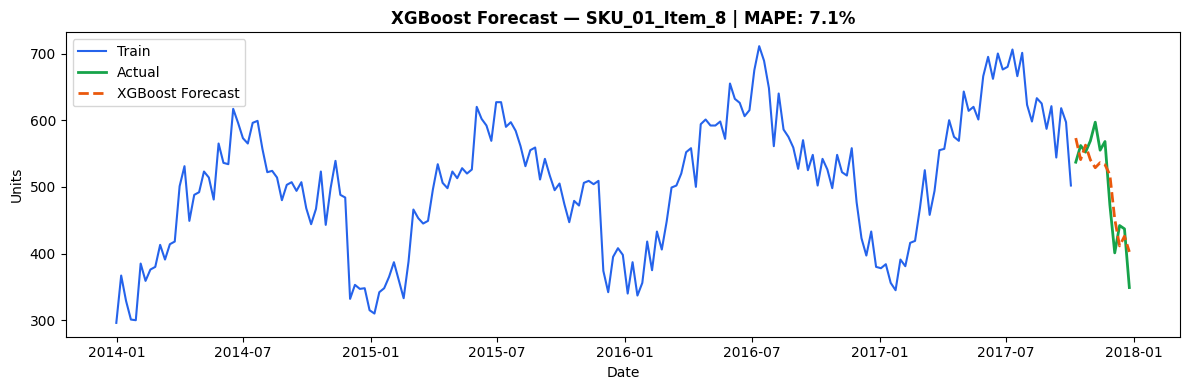

In [8]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE     = True   # Set to False for a fast run
N_TRIALS = 20     # How many hyperparameter combos Optuna tries

def run_xgboost(X_train, y_train, X_test, tune=True, n_trials=20):
    tscv = TimeSeriesSplit(n_splits=4)

    if tune:
        def objective(trial):
            params = {
                "n_estimators":     trial.suggest_int("n_estimators", 100, 400),
                "max_depth":        trial.suggest_int("max_depth", 3, 7),
                "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2),
                "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "random_state": 42, "verbosity": 0
            }
            m = XGBRegressor(**params)
            scores = cross_val_score(m, X_train, y_train,
                                     cv=tscv, scoring="neg_mean_absolute_error")
            return -scores.mean()

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=n_trials)
        best_params = {**study.best_params, "random_state": 42, "verbosity": 0}
        print(f"  Best params: {best_params}")
    else:
        best_params = {"n_estimators":200, "max_depth":5, "learning_rate":0.05,
                       "random_state":42, "verbosity":0}

    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    preds = np.maximum(0, model.predict(X_test))
    return preds, model, best_params

# ── Test XGBoost on same SKU ──────────────────────────────────────────────────
feat_cols  = get_feature_cols(df_feat)
train_xgb, test_xgb = split_sku(df_feat, TEST_SKU, TEST_WEEKS)

preds_xgb, xgb_model, best_params = run_xgboost(
    train_xgb[feat_cols], train_xgb["demand"],
    test_xgb[feat_cols],  tune=TUNE, n_trials=N_TRIALS
)
metrics_xgb = calc_metrics(test_xgb["demand"].values, preds_xgb)

print(f"\n✅ XGBoost on {TEST_SKU}")
print(f"Metrics: {metrics_xgb}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_xgb["date"], train_xgb["demand"],
        label="Train", color="#2563EB", linewidth=1.5)
ax.plot(test_xgb["date"], test_xgb["demand"],
        label="Actual", color="#16A34A", linewidth=2)
ax.plot(test_xgb["date"], preds_xgb,
        label="XGBoost Forecast", color="#EA580C", linewidth=2, linestyle="--")
ax.set_title(f"XGBoost Forecast — {TEST_SKU} | MAPE: {metrics_xgb['MAPE%']:.1f}%", fontweight="bold")
ax.legend(); ax.set_xlabel("Date"); ax.set_ylabel("Units")
plt.tight_layout(); plt.savefig("xgboost_forecast.png", dpi=120, bbox_inches="tight"); plt.show()

## 🔍 Step 5 — Feature Importance (XGBoost)

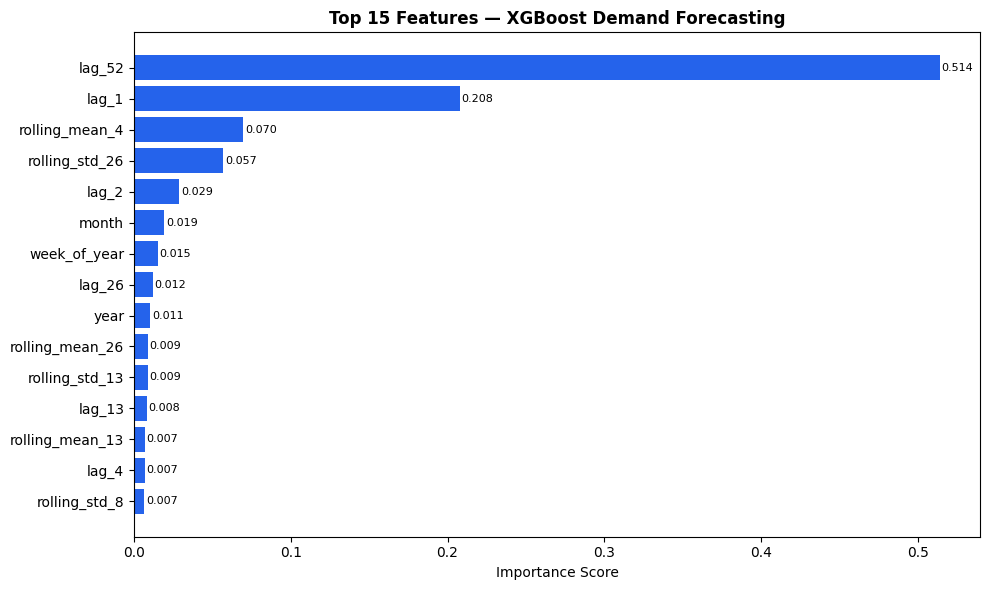

✅ Feature importance saved


In [9]:
# Which features helped XGBoost the most?
fi_df = (pd.DataFrame({"feature": feat_cols,
                        "importance": xgb_model.feature_importances_})
           .sort_values("importance", ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="#2563EB")
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Features — XGBoost Demand Forecasting", fontweight="bold")
for bar, val in zip(bars, fi_df["importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Feature importance saved")

## 🏆 Step 6 — Full Model Comparison (All 12 SKUs)

Now we run all 3 models on all 12 SKUs and compare them.  
> ⏱️ This takes **10–20 minutes** in Colab. You can reduce it by setting `TUNE=False`.


In [10]:
TEST_WEEKS = 12
TUNE       = False   # Set True for better accuracy (slower)
N_TRIALS   = 15

all_results = []
os.makedirs("models", exist_ok=True)

for i, sku in enumerate(skus):
    print(f"[{i+1}/{len(skus)}] Processing {sku}...")
    raw_s     = df_weekly[df_weekly["sku"]==sku].sort_values("date")
    actual    = raw_s["demand"].iloc[-TEST_WEEKS:].values
    train_raw = raw_s.iloc[:-TEST_WEEKS]

    # ARIMA
    try:
        p, o = run_arima(raw_s["demand"].iloc[:-TEST_WEEKS], TEST_WEEKS)
        m    = calc_metrics(actual, p)
        all_results.append({"sku":sku, "model":"ARIMA", "order":str(o), **m})
        print(f"  ARIMA   MAPE: {m['MAPE%']:.1f}%")
    except Exception as e:
        print(f"  ARIMA failed: {e}")

    # Prophet
    try:
        p, _ = run_prophet(train_raw, TEST_WEEKS)
        m    = calc_metrics(actual, p)
        all_results.append({"sku":sku, "model":"Prophet", "order":"-", **m})
        print(f"  Prophet MAPE: {m['MAPE%']:.1f}%")
    except Exception as e:
        print(f"  Prophet failed: {e}")

    # XGBoost
    try:
        tr, te = split_sku(df_feat, sku, TEST_WEEKS)
        fc     = get_feature_cols(df_feat)
        p, mdl, _ = run_xgboost(tr[fc], tr["demand"], te[fc],
                                 tune=TUNE, n_trials=N_TRIALS)
        m = calc_metrics(actual, p)
        all_results.append({"sku":sku, "model":"XGBoost", "order":"-", **m})
        joblib.dump(mdl, f"models/{sku}_xgboost.pkl")
        print(f"  XGBoost MAPE: {m['MAPE%']:.1f}%")
    except Exception as e:
        print(f"  XGBoost failed: {e}")
    print()

# Save results
results_df = pd.DataFrame(all_results)
os.makedirs("reports", exist_ok=True)
results_df.to_csv("reports/model_comparison.csv", index=False)

print("\n✅ All models done! Saved: reports/model_comparison.csv")
print("\n=== Average MAPE by Model (lower = better) ===")
print(results_df.groupby("model")["MAPE%"].mean().round(2).sort_values())

[1/12] Processing SKU_01_Item_8...


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  ARIMA   MAPE: 14.8%
  Prophet MAPE: 6.0%
  XGBoost MAPE: 6.4%

[2/12] Processing SKU_02_Item_10...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

  ARIMA   MAPE: 14.8%
  Prophet MAPE: 5.4%
  XGBoost MAPE: 5.9%

[3/12] Processing SKU_03_Item_12...


...

  ARIMA   MAPE: 15.2%
  Prophet MAPE: 4.9%
  XGBoost MAPE: 7.3%

[11/12] Processing SKU_11_Item_38...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

  ARIMA   MAPE: 13.3%
  Prophet MAPE: 6.6%
  XGBoost MAPE: 4.2%

[12/12] Processing SKU_12_Item_45...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

  ARIMA   MAPE: 15.3%
  Prophet MAPE: 4.8%
  XGBoost MAPE: 7.6%


✅ All models done! Saved: reports/model_comparison.csv

=== Average MAPE by Model (lower = better) ===
model
Prophet     6.07
XGBoost     6.61
ARIMA      15.49
Name: MAPE%, dtype: float64


## 📊 Step 7 — Leaderboard Visualisation

           MAE   RMSE  MAPE%
model                       
Prophet  29.34  35.94   6.07
XGBoost  32.96  40.24   6.61
ARIMA    71.44  90.11  15.49


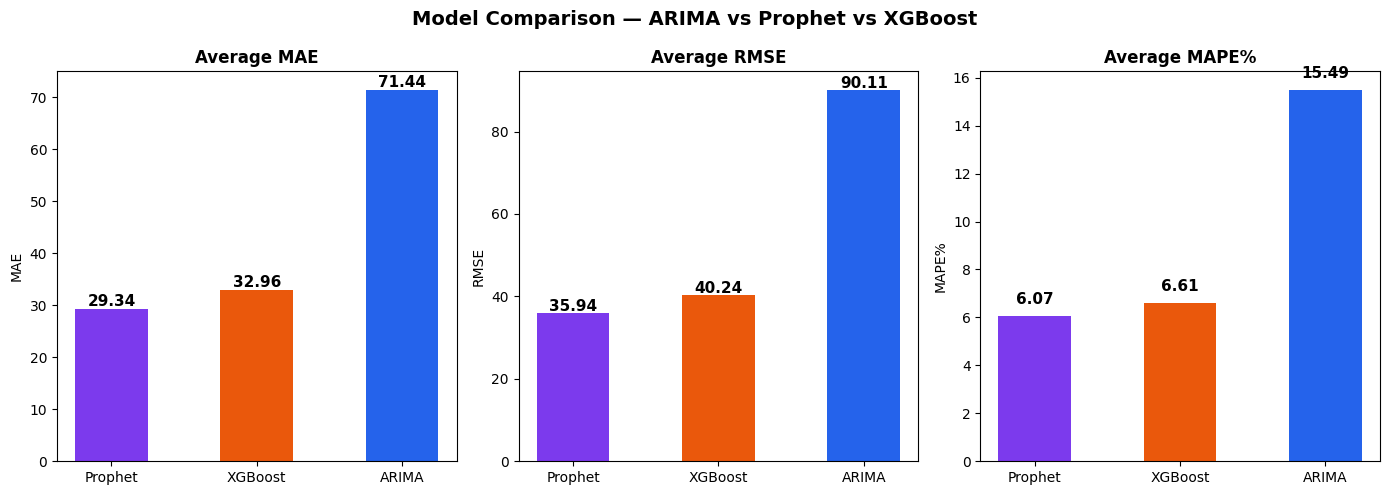

✅ Chart saved as model_comparison_chart.png


In [11]:
results_df = pd.read_csv("reports/model_comparison.csv")

# Bar chart: average MAPE per model
summary = results_df.groupby("model")[["MAE","RMSE","MAPE%"]].mean().round(2).sort_values("MAPE%")
print(summary)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = {"ARIMA":"#2563EB", "Prophet":"#7C3AED", "XGBoost":"#EA580C"}

for ax, metric in zip(axes, ["MAE","RMSE","MAPE%"]):
    vals  = summary[metric]
    bars  = ax.bar(vals.index, vals.values,
                   color=[colors[m] for m in vals.index], width=0.5)
    ax.set_title(f"Average {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha="center", fontweight="bold", fontsize=11)

plt.suptitle("Model Comparison — ARIMA vs Prophet vs XGBoost", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Chart saved as model_comparison_chart.png")

## 📈 Step 8 — Interactive Forecast Chart (Plotly)
Hover over the chart to see exact values.

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pick any SKU to explore interactively
EXPLORE_SKU = skus[0]   # Change this to any SKU name

raw_s      = df_weekly[df_weekly["sku"]==EXPLORE_SKU].sort_values("date")
actual_v   = raw_s["demand"].iloc[-TEST_WEEKS:].values
train_raw  = raw_s.iloc[:-TEST_WEEKS]
tr, te     = split_sku(df_feat, EXPLORE_SKU, TEST_WEEKS)
fc         = get_feature_cols(df_feat)

# Get all 3 forecasts
p_arima, _    = run_arima(raw_s["demand"].iloc[:-TEST_WEEKS], TEST_WEEKS)
p_prophet, _  = run_prophet(train_raw, TEST_WEEKS)
p_xgb, _, _   = run_xgboost(tr[fc], tr["demand"], te[fc], tune=False)

test_dates  = raw_s["date"].iloc[-TEST_WEEKS:].tolist()
train_dates = raw_s["date"].iloc[:-TEST_WEEKS].tolist()
train_vals  = raw_s["demand"].iloc[:-TEST_WEEKS].tolist()

fig = go.Figure()
fig.add_trace(go.Scatter(x=train_dates, y=train_vals,
    name="Historical", mode="lines", line=dict(color="#2563EB", width=1.5)))
fig.add_trace(go.Scatter(x=test_dates, y=actual_v.tolist(),
    name="Actual", mode="lines+markers", line=dict(color="#16A34A", width=2.5)))
fig.add_trace(go.Scatter(x=test_dates, y=p_arima.tolist(),
    name="ARIMA", mode="lines+markers", line=dict(color="#DC2626", dash="dash", width=2)))
fig.add_trace(go.Scatter(x=test_dates, y=p_prophet.tolist(),
    name="Prophet", mode="lines+markers", line=dict(color="#7C3AED", dash="dot", width=2)))
fig.add_trace(go.Scatter(x=test_dates, y=p_xgb.tolist(),
    name="XGBoost", mode="lines+markers", line=dict(color="#EA580C", dash="dashdot", width=2)))

fig.update_layout(
    title=f"All 3 Models — {EXPLORE_SKU}",
    xaxis_title="Date", yaxis_title="Weekly Demand",
    legend=dict(orientation="h", y=1.1),
    hovermode="x unified", height=450,
    template="plotly_white"
)
fig.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## 🌐 Step 9 — Launch Streamlit Dashboard

This launches the full interactive web app.  
You will get a **public URL** (from ngrok) — open it in any browser.  

> ⏱️ Takes about 30 seconds to start up.


In [14]:
# ── Step 9 — Launch Streamlit App ─────────────────────────────────────────
!pip install -q pyngrok streamlit

import subprocess, time
from pyngrok import ngrok, conf

# ── PASTE YOUR NGROK TOKEN HERE ──────────────────────────────────────────────
NGROK_TOKEN = "3CGJcctOdtDEZfQLddZwQbb3fyU_6ygtH3cznzR1PN4biiAsi"   # ← replace this
# ─────────────────────────────────────────────────────────────────────────────

# Set the token
conf.get_default().auth_token = NGROK_TOKEN

# Write the Streamlit app file
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

st.set_page_config(page_title="Demand Forecasting", page_icon="📦", layout="wide")
st.title("📦 Multi-SKU Demand Forecasting Engine")
st.markdown("**Gaurav Bhatia** — MSc Data Science | GISMA University, Berlin")

@st.cache_data
def load():
    raw = pd.read_csv("weekly_sales.csv", parse_dates=["date"])
    return raw

def eng(df):
    df = df.copy().sort_values(["sku","date"]).reset_index(drop=True)
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["month"]  = df["date"].dt.month
    df["quarter"]= df["date"].dt.quarter
    df["year"]   = df["date"].dt.year
    for lag in [1,2,4,8,13,26,52]:
        df[f"lag_{lag}"] = df.groupby("sku")["demand"].shift(lag)
    for w in [4,8,13,26]:
        df[f"roll_mean_{w}"] = df.groupby("sku")["demand"].transform(lambda x: x.shift(1).rolling(w).mean())
        df[f"roll_std_{w}"]  = df.groupby("sku")["demand"].transform(lambda x: x.shift(1).rolling(w).std())
    return df.dropna().reset_index(drop=True)

def calc(a,p):
    return {"MAE":round(float(np.mean(np.abs(a-p))),2),
            "RMSE":round(float(np.sqrt(np.mean((a-p)**2))),2),
            "MAPE%":round(float(np.mean(np.abs((a-p)/np.maximum(a,1)))*100),2)}

try:
    raw = load()
except:
    st.error("weekly_sales.csv not found. Run Step 2 first."); st.stop()

feat = eng(raw)
skus = sorted(feat["sku"].unique())
fc   = [c for c in feat.columns if c not in ["date","sku","demand"]]

st.sidebar.header("⚙️ Settings")
sku   = st.sidebar.selectbox("Select SKU", skus)
model = st.sidebar.selectbox("Select Model", ["ARIMA","Prophet","XGBoost"])
tw    = st.sidebar.slider("Test weeks", 4, 24, 12)

raw_s = raw[raw["sku"]==sku].sort_values("date")
s     = feat[feat["sku"]==sku].reset_index(drop=True)
tr, te = s.iloc[:-tw], s.iloc[-tw:]
actual = te["demand"].values

with st.spinner(f"Running {model}..."):
    if model == "ARIMA":
        baic, bo = np.inf, (1,1,1)
        for p,d,q in product(range(3),range(2),range(3)):
            try:
                r = ARIMA(raw_s["demand"].iloc[:-tw], order=(p,d,q)).fit()
                if r.aic < baic: baic, bo = r.aic, (p,d,q)
            except: pass
        prd = np.maximum(0, ARIMA(raw_s["demand"].iloc[:-tw], order=bo).fit().forecast(tw).values)
    elif model == "Prophet":
        pdf = raw_s.iloc[:-tw][["date","demand"]].rename(columns={"date":"ds","demand":"y"})
        mp  = Prophet(yearly_seasonality=True, weekly_seasonality=False)
        mp.fit(pdf)
        prd = np.maximum(0, mp.predict(mp.make_future_dataframe(tw,"W"))["yhat"].values[-tw:])
    else:
        mx  = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                           random_state=42, verbosity=0)
        mx.fit(tr[fc], tr["demand"])
        prd = np.maximum(0, mx.predict(te[fc]))

    met = calc(actual, prd)

c1,c2,c3 = st.columns(3)
c1.metric("MAE",  f"{met['MAE']:.1f} units")
c2.metric("RMSE", f"{met['RMSE']:.1f} units")
c3.metric("MAPE", f"{met['MAPE%']:.1f}%")

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(tr["date"]), y=tr["demand"].tolist(),
    name="Train", line=dict(color="#2563EB", width=1.5)))
fig.add_trace(go.Scatter(x=list(te["date"]), y=actual.tolist(),
    name="Actual", line=dict(color="#16A34A", width=2.5)))
fig.add_trace(go.Scatter(x=list(te["date"]), y=prd.tolist(),
    name=f"{model} Forecast", line=dict(color="#DC2626", dash="dash", width=2.5)))
fig.update_layout(
    title=f"{sku} — {model} Forecast",
    xaxis_title="Date", yaxis_title="Weekly Demand",
    legend=dict(orientation="h", y=1.1),
    hovermode="x unified", height=430, template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)
st.divider()
st.markdown("**Gaurav Bhatia** · [LinkedIn](https://linkedin.com/in/gaurav-bhatia-5a5a83184)")
"""

with open("streamlit_app.py", "w") as f:
    f.write(app_code)

# Kill any old tunnels
ngrok.kill()

# Start Streamlit
proc = subprocess.Popen(
    ["streamlit", "run", "streamlit_app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false",
     "--server.enableXsrfProtection=false"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(5)   # wait for Streamlit to start

# Create public URL
public_url = ngrok.connect(8501)
print("=" * 50)
print(f"🚀 App is LIVE!")
print(f"👉 Open this link: {public_url}")
print("=" * 50)
print("\nKeep this cell running. Stop it (■) to shut down the app.")
proc.wait()

🚀 App is LIVE!
👉 Open this link: NgrokTunnel: "https://repackage-headwear-vascular.ngrok-free.dev" -> "http://localhost:8501"

Keep this cell running. Stop it (■) to shut down the app.


1